# 🎯 Optimización con Optuna — Random Forest — 4 herramientas

Optuna busca los mejores hiperparámetros de RF automáticamente.

## Sin trampa (fuga del test)
El test no se toca durante la búsqueda. Optuna optimiza sobre una validación separada; al final se reentrena con todo el train y se evalúa una vez en test.

## Configuración
- RF **no usa GPU**, va en CPU con todos los núcleos (`n_jobs=-1`).
- `N_TRIALS = 100` por herramienta.
- Perillas: n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf.

**Si falta Optuna:** `pip install optuna`

**Run All y listo.**


In [1]:
# ============================================================
# CELDA 0 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd, numpy as np, time, gc
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

BASE_IN = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')
CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']
SEED = 42
N_TRIALS = 100

print(f'Optuna trials por herramienta: {N_TRIALS} (Random Forest, CPU)')

/home/miguel/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna trials por herramienta: 100 (Random Forest, CPU)


In [2]:
# ============================================================
# CELDA 1 — FUNCIÓN cargar_datos (idéntica a la del notebook RF)
# Devuelve (X, y) listos para entrenar, con las mismas reglas de
# filtrado: solo columnas comunes y eliminando sospechosas de fuga.
# ============================================================

def cargar_datos(herramienta, usar_solo_columnas_comunes=True, eliminar_sospechosas=True):
    dfs_por_clase = {}
    columnas_por_clase = {}

    for clase in CLASES:
        ruta = BASE_IN / clase / f'{herramienta}.csv'
        df_tmp = pd.read_csv(ruta, low_memory=False)
        dfs_por_clase[clase] = df_tmp
        columnas_por_clase[clase] = list(df_tmp.columns)

    print('\n' + '='*80)
    print(f'CARGA — {herramienta}')
    print('='*80)

    for clase in CLASES:
        df_tmp = dfs_por_clase[clase]
        print(f'{clase:<25} {df_tmp.shape[0]:,} filas x {df_tmp.shape[1]} columnas')

    conjuntos = [set(columnas_por_clase[clase]) for clase in CLASES]
    columnas_comunes_set = set.intersection(*conjuntos)
    columnas_union_set   = set.union(*conjuntos)

    if usar_solo_columnas_comunes:
        columnas_base = [c for c in columnas_por_clase[CLASES[0]] if c in columnas_comunes_set]
    else:
        columnas_base = sorted(columnas_union_set)

    patrones_fuga = [
        'label', 'etiqueta', 'class', 'attack', 'category', 'subtipo',
        'archivo', 'file', 'pcap',
        'flow_id', 'macaddr', 'mac', 'src_mac', 'dst_mac',
        'fqdn', 'sni', 'scn', 'dns_rslv', 'tls_sesid', 'npnalpn', 'alpn',
        'first_abs', 'req_tm', 'res_tm', 'handshaket', 'appdatat',
    ]

    columnas_id_exactas = {'id', 'ID', 'Flow ID', 'FLOW_ID', 'flow_id', 'uint64 FLOW_ID'}

    columnas_temporales_peligrosas_exactas = {
        'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
        'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP',
        'last', 'req_tm', 'res_tm', 's_first_abs',
        'c_first', 's_first', 'c_last', 's_last',
        'c_first_ack', 's_first_ack',
        'c_last_handshakeT', 's_last_handshakeT',
        'c_appdataT', 's_appdataT',
    }

    columnas_sospechosas = []
    if eliminar_sospechosas:
        for col in columnas_base:
            col_lower = col.lower()
            es_sospechosa_por_patron = any(p in col_lower for p in patrones_fuga)
            es_id = col in columnas_id_exactas or col_lower in columnas_id_exactas
            es_temporal_peligrosa = (
                col in columnas_temporales_peligrosas_exactas
                or col_lower in columnas_temporales_peligrosas_exactas
                or col_lower.startswith('time_ppi_pkt_times_')
            )
            if es_sospechosa_por_patron or es_id or es_temporal_peligrosa:
                columnas_sospechosas.append(col)

    if columnas_sospechosas:
        print(f'\n[{herramienta}] Columnas eliminadas por posible fuga directa: {len(columnas_sospechosas)}')

    columnas_finales = [c for c in columnas_base if c not in columnas_sospechosas]
    print(f'[{herramienta}] Columnas finales antes de concatenar: {len(columnas_finales)}')

    dfs = []
    for clase in CLASES:
        df_tmp = dfs_por_clase[clase][columnas_finales].copy()
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True, sort=False)
    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    cols_obj = X.select_dtypes(include=['object']).columns.tolist()
    if cols_obj:
        print(f'[{herramienta}] Columnas object codificadas con LabelEncoder: {len(cols_obj)}')
    for col in cols_obj:
        X[col] = X[col].fillna('__missing__').astype(str)
        X[col] = LabelEncoder().fit_transform(X[col])

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    cols_constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if cols_constantes:
        print(f'[{herramienta}] Columnas constantes eliminadas tras concatenar: {len(cols_constantes)}')
        X = X.drop(columns=cols_constantes)

    print(f'[{herramienta}] Shape final X: {X.shape}')
    return X, y

In [3]:
# ============================================================
# CELDA 2 — OPTIMIZACIÓN OPTUNA + EVALUACIÓN (Random Forest)
# ============================================================

def optimizar_y_evaluar_rf(X, y, herramienta, n_trials=N_TRIALS):
    le_y = LabelEncoder(); y_enc = le_y.fit_transform(y)
    nombres_clase = list(le_y.classes_)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)

    def objetivo(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
            'max_depth':         trial.suggest_int('max_depth', 3, 30),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        }
        modelo = RandomForestClassifier(**params, random_state=SEED, n_jobs=4)
        modelo.fit(X_tr, y_tr)
        return f1_score(y_val, modelo.predict(X_val), average='macro')

    print(f'\n[{herramienta}] Optimizando ({n_trials} trials)...')
    t0 = time.time()
    estudio = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
    estudio.optimize(objetivo, n_trials=n_trials)
    t_opt = time.time() - t0

    mejores = estudio.best_params
    print(f'[{herramienta}] Búsqueda en {t_opt:.1f}s | Mejor F1 val: {estudio.best_value:.4f}')
    for k, v in mejores.items(): print(f'      {k}: {v}')

    modelo_final = RandomForestClassifier(**mejores, random_state=SEED, n_jobs=4)
    t0 = time.time(); modelo_final.fit(X_train, y_train); t_train = time.time()-t0
    t0 = time.time(); y_pred = modelo_final.predict(X_test); t_pred = time.time()-t0

    n_test = len(X_test)
    metricas = {'Herramienta':herramienta,'N features':X.shape[1],
        'Accuracy':accuracy_score(y_test,y_pred),'F1 macro':f1_score(y_test,y_pred,average='macro'),
        'Recall macro':recall_score(y_test,y_pred,average='macro'),
        'Precision macro':precision_score(y_test,y_pred,average='macro'),
        'Tiempo opt (s)':t_opt,'Tiempo train (s)':t_train,'Tiempo pred (s)':t_pred,
        'Pred us/muestra':(t_pred/n_test)*1e6}
    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(nombres_clase))))
    print(f'[{herramienta}] TEST -> Acc: {metricas["Accuracy"]:.4f}  F1: {metricas["F1 macro"]:.4f}')
    return metricas, cm, nombres_clase, mejores

In [4]:
# ============================================================
# CELDA 3 — BUCLE PRINCIPAL: las 4 herramientas
# ============================================================

resultados = []
matrices_dict = {}
nombres_dict = {}
params_dict = {}

for herr in HERRAMIENTAS:
    print('\n' + '#'*80)
    print(f'#  PROCESANDO {herr}')
    print('#'*80)

    X, y = cargar_datos(herr, usar_solo_columnas_comunes=True, eliminar_sospechosas=True)
    metricas, cm, nombres, mejores = optimizar_y_evaluar_rf(X, y, herr)

    resultados.append(metricas)
    matrices_dict[herr] = cm
    nombres_dict[herr] = nombres
    params_dict[herr] = mejores

    del X, y
    gc.collect()


################################################################################
#  PROCESANDO CIC
################################################################################

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas eliminadas por posible fuga directa: 1
[CIC] Columnas finales antes de concatenar: 70
[CIC] Columnas constantes eliminadas tras concatenar: 1
[CIC] Shape final X: (27848, 69)

[CIC] Optimizando (100 trials)...
[CIC] Búsqueda en 2403.0s | Mejor F1 val: 0.7208
      n_estimators: 599
      max_depth: 20
      max_features: log2
      min_samples_split: 10
      min_samples_

In [5]:
# ============================================================
# CELDA 4 — TABLA COMPARATIVA FINAL
# ============================================================

df_res = pd.DataFrame(resultados)

print('='*120)
print('  TABLA — Random Forest optimizado con Optuna')
print('='*120)

df_show = df_res.copy()
for col in ['Accuracy', 'F1 macro', 'Recall macro', 'Precision macro']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.4f}')
for col in ['Tiempo opt (s)', 'Tiempo train (s)', 'Tiempo pred (s)']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.1f}')
df_show['Pred us/muestra'] = df_show['Pred us/muestra'].map(lambda v: f'{v:.1f}')

print(df_show.to_string(index=False))

print('\n' + '='*120)
print('  COMPARACIÓN F1 macro: RF básico vs RF+Optuna')
print('='*120)
print('  Herramienta   Básico    Optuna    Mejora')
basico = {'CIC': 0.7099, 'Nemea': 0.5829, 'Tstat': 0.6311, 'Tshark': 0.7434}
for r in resultados:
    h = r['Herramienta']
    b = basico[h]
    o = r['F1 macro']
    print(f'  {h:<12} {b:.4f}    {o:.4f}    {o-b:+.4f}')

  TABLA — Random Forest optimizado con Optuna
Herramienta  N features Accuracy F1 macro Recall macro Precision macro Tiempo opt (s) Tiempo train (s) Tiempo pred (s) Pred us/muestra
        CIC          69   0.7363   0.7355       0.7362          0.7401         2403.0             25.5             0.6           116.7
      Nemea         148   0.6039   0.5885       0.6039          0.6326         1487.4             11.1             0.4            64.5
      Tstat          96   0.6363   0.6317       0.6362          0.6728          772.2              6.2             0.3            46.8
     Tshark          50   0.7562   0.7558       0.7562          0.7596         1616.3             14.1             0.3            50.2

  COMPARACIÓN F1 macro: RF básico vs RF+Optuna
  Herramienta   Básico    Optuna    Mejora
  CIC          0.7099    0.7355    +0.0256
  Nemea        0.5829    0.5885    +0.0056
  Tstat        0.6311    0.6317    +0.0006
  Tshark       0.7434    0.7558    +0.0124


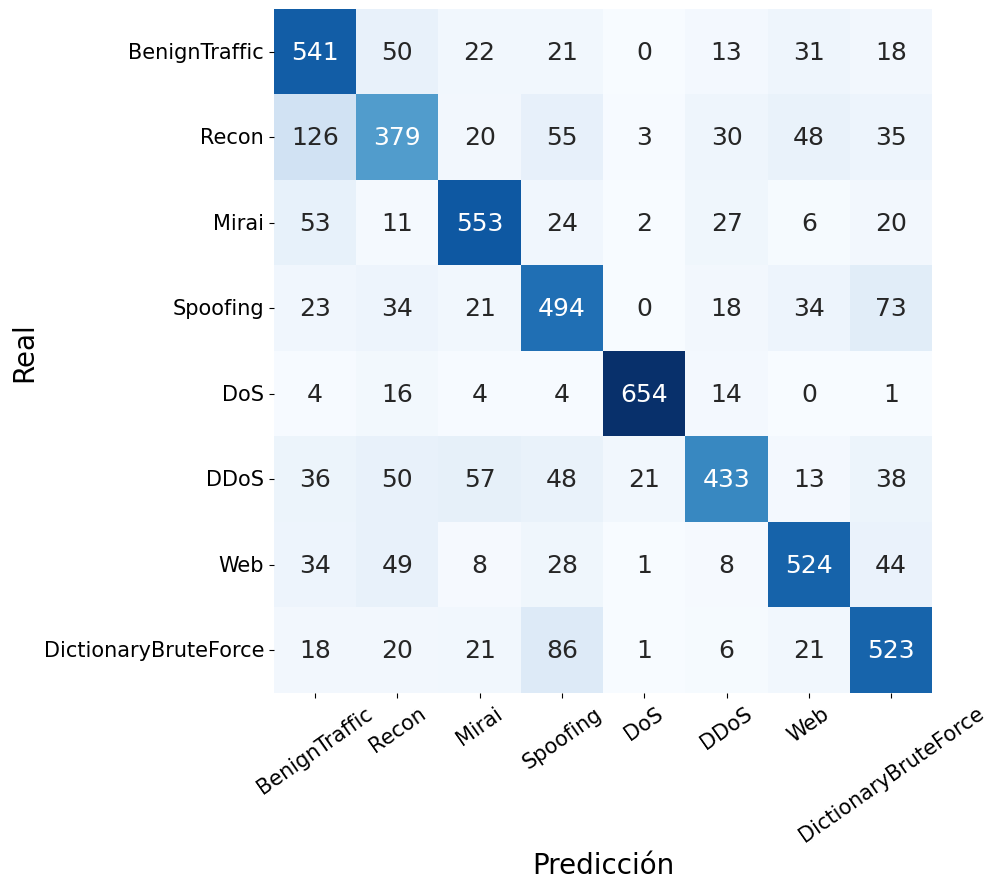

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_optuna_CIC.pdf


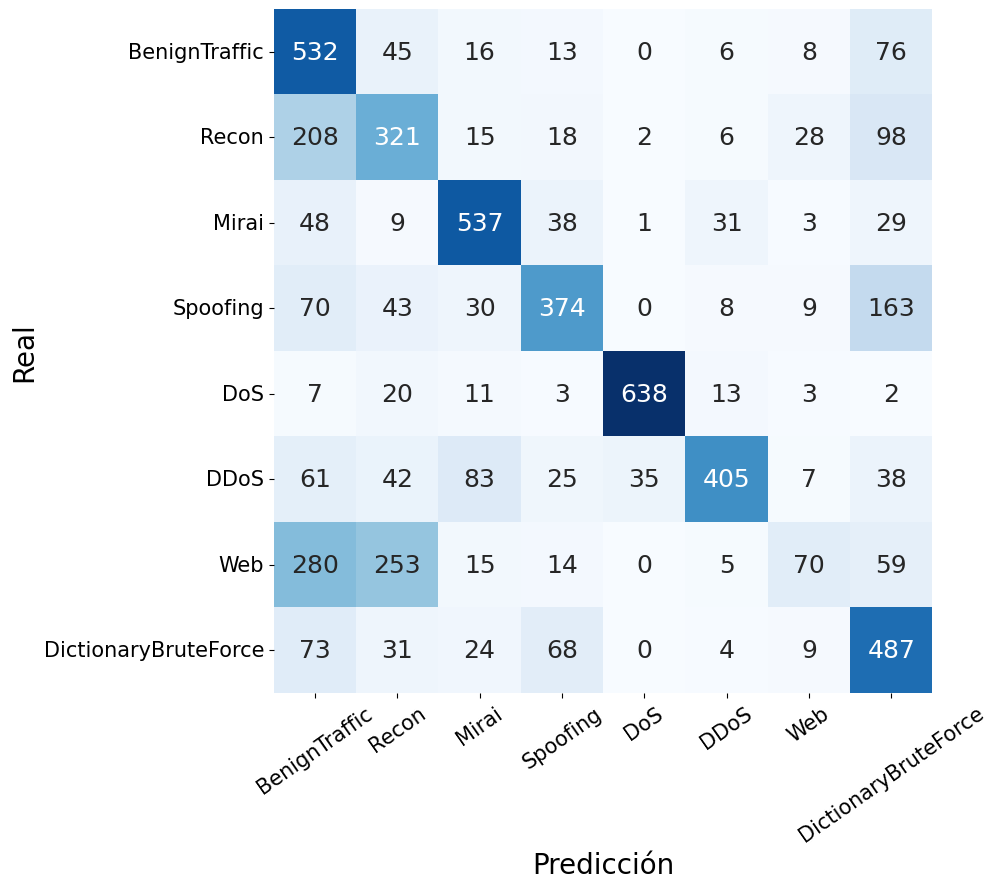

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_optuna_Nemea.pdf


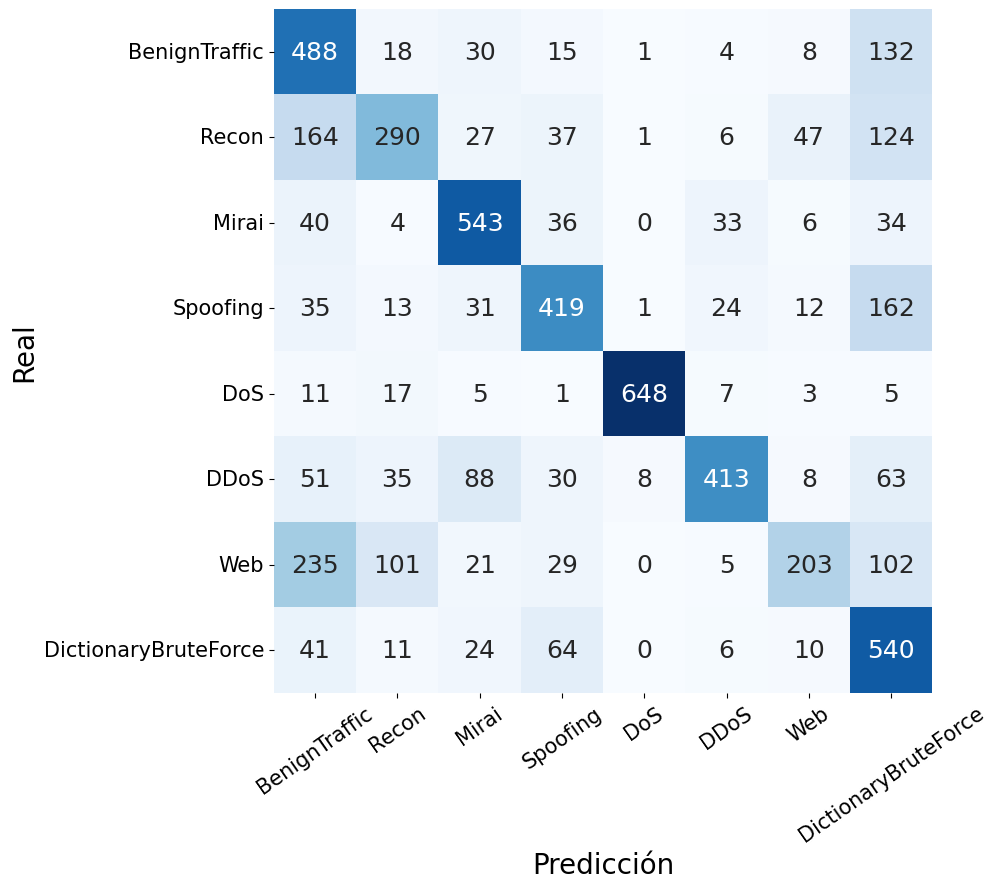

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_optuna_Tstat.pdf


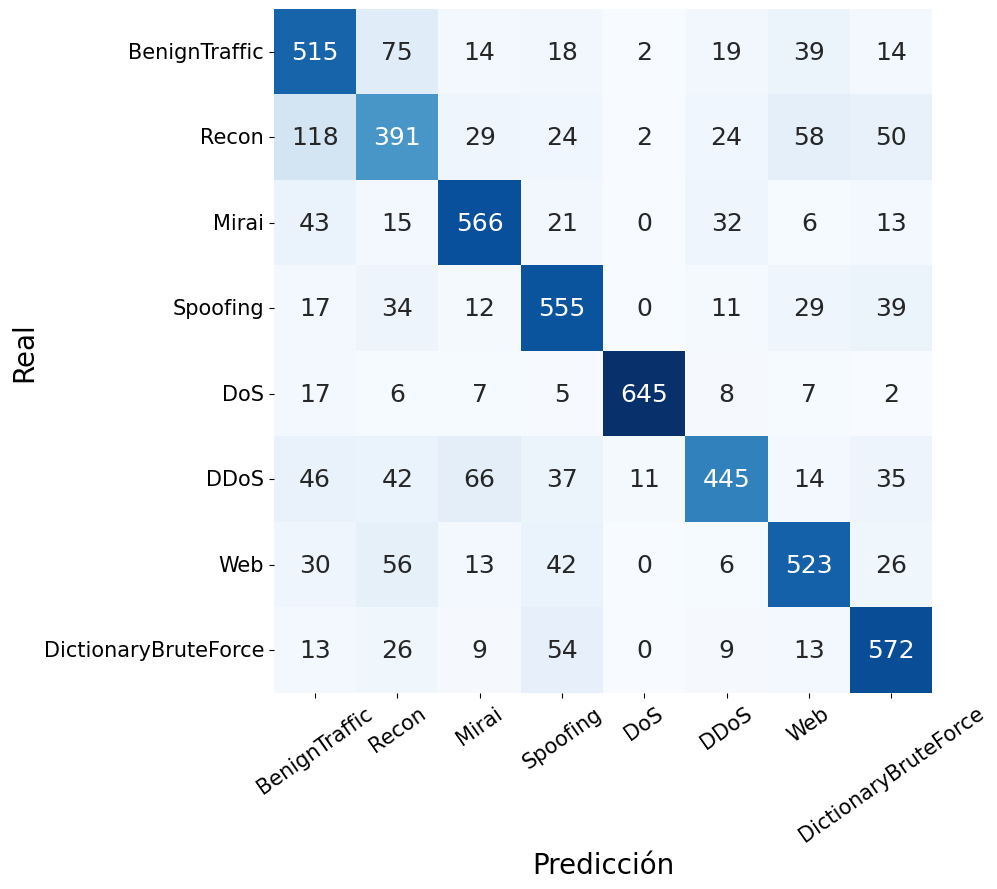

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_optuna_Tshark.pdf


In [6]:
# ============================================================
# CELDA 5 — MATRICES DE CONFUSIÓN (4 PDF separados, orden fijo de clases)
# ============================================================

RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

ORDEN_FIGURA = ['BenignTraffic', 'Recon', 'Mirai', 'Spoofing',
                'DoS', 'DDoS', 'Web', 'DictionaryBruteForce']

for herr in HERRAMIENTAS:
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]          # orden alfabético (el que da LabelEncoder)

    # Reordenar filas y columnas de la matriz al orden fijo de ORDEN_FIGURA
    perm = [nombres.index(c) for c in ORDEN_FIGURA]
    cm_ordenada = cm[perm][:, perm]

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.heatmap(cm_ordenada, annot=True, fmt='d', cmap='Blues',
                xticklabels=ORDEN_FIGURA, yticklabels=ORDEN_FIGURA,
                cbar=False, ax=ax, annot_kws={'size': 18})

    ax.set_xlabel('Predicción', fontsize=20)
    ax.set_ylabel('Real', fontsize=20)
    ax.tick_params(axis='x', rotation=35, labelsize=15)
    ax.tick_params(axis='y', rotation=0,  labelsize=15)

    plt.tight_layout()

    ruta_pdf = RUTA_FIGURAS / f'cm_rf_optuna_{herr}.pdf'
    fig.savefig(ruta_pdf, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'✓ Guardado: {ruta_pdf}')

In [ ]:
# CELDA THROUGHPUT — RF + Optuna
import numpy as np

N_TEST = 5570  # 20% de 27848

BYTES_MEDIO_FLUJO = {
    'CIC':    116,
    'Nemea':  247,
    'Tstat':  114,
    'Tshark': 206
}

print('\n' + '='*70)
print('  THROUGHPUT — RF + Optuna')
print('='*70)
print(f'  {"Herramienta":10s}  {"µs/muestra":12s}  {"Flujos/s":12s}  {"Throughput (Mbps)":18s}')
print(f'  {"-"*10}  {"-"*12}  {"-"*12}  {"-"*18}')

for r in resultados:
    herr = r['Herramienta']
    us_muestra = r['Pred us/muestra']
    flujos_s = 1e6 / us_muestra
    bytes_medio = BYTES_MEDIO_FLUJO[herr]
    throughput_mbps = (flujos_s * bytes_medio * 8) / 1e6
    print(f'  {herr:10s}  {us_muestra:12.1f}  {flujos_s:12.0f}  {throughput_mbps:18.1f}')


  THROUGHPUT — RF + Optuna
  Herramienta  µs/muestra    Flujos/s      Throughput (Mbps) 
  ----------  ------------  ------------  ------------------
  CIC                116.7          8572                 3.3
  Nemea               64.5         15492                12.5
  Tstat               46.8         21363                 8.7
  Tshark              50.2         19910                32.8
